<a href="https://colab.research.google.com/github/Shubhranshu331/Amazon-reviews-vader-Sentiment-analysis/blob/main/amazon_food_review_sentiment_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Amazon Fine Food Reviews — Sentiment Analysis

**Dataset:** Amazon Fine Food Reviews (Kaggle)  
**Tool:** VADER (Valence Aware Dictionary and sEntiment Reasoner)  
**Author:** [Your Name]  
**Environment:** Google Colab

---

## 1. Problem Statement

Online product reviews carry a lot of signal — they tell us how customers feel about a product, often more directly than star ratings alone. In this project, I analyze Amazon Fine Food Reviews using **VADER sentiment analysis** to classify each review as Positive, Neutral, or Negative based on its text content.

The goal is straightforward:
- Understand the sentiment distribution across reviews
- See how VADER-assigned sentiment compares with the original star ratings
- Extract some practical insights from the data

This is a rule-based NLP approach — no training required — which makes it a solid baseline for text sentiment tasks.

---
## 2. Import Libraries

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter

import nltk
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from wordcloud import WordCloud

# Download required NLTK resources
nltk.download('vader_lexicon', quiet=True)
nltk.download('stopwords', quiet=True)

# Plot styling
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})
sns.set_style('whitegrid')

print('All libraries loaded.')

All libraries loaded.


---
## 3. Load Dataset

In [6]:
# If running locally, update this path to where Reviews.csv is saved on your machine
# In Colab: upload the file manually or mount Google Drive

from google.colab import files
uploaded = files.upload()
df = pd.read_csv('Reviews.csv')

print(f'Dataset loaded: {df.shape[0]:,} rows, {df.shape[1]} columns')

Saving Reviews.csv to Reviews.csv
Dataset loaded: 568,454 rows, 10 columns


---
## 4. Dataset Overview

In [8]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [10]:
# Column-level null counts
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [11]:
# Star rating distribution
print('Score distribution:')
print(df['Score'].value_counts().sort_index())

Score distribution:
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64


**Key observations:**
- The dataset has ~568K reviews across 10 columns.
- `ProfileName` and `Summary` have a small number of nulls.
- `Score` (1–5 stars) is our reference label for validation later.
- `Text` is the primary column we'll analyze.

---
## 5. Data Cleaning

In [12]:
# Work on a copy — keeps the original intact
df_clean = df.copy()

# Drop rows where review text is missing
df_clean.dropna(subset=['Text'], inplace=True)

# Remove exact duplicate review texts
print(f'Duplicates found: {df_clean["Text"].duplicated().sum():,}')
df_clean.drop_duplicates(subset='Text', inplace=True)

# Reset index after cleaning
df_clean.reset_index(drop=True, inplace=True)

print(f'Rows after cleaning: {df_clean.shape[0]:,}')

Duplicates found: 174,875
Rows after cleaning: 393,579


In [13]:
# For this project, we work with a sample of 10,000 reviews
# This keeps runtime manageable without losing much representativeness
df_sample = df_clean.sample(n=10000, random_state=42).reset_index(drop=True)

print(f'Working sample size: {df_sample.shape[0]:,}')

Working sample size: 10,000


---
## 6. Exploratory Data Analysis

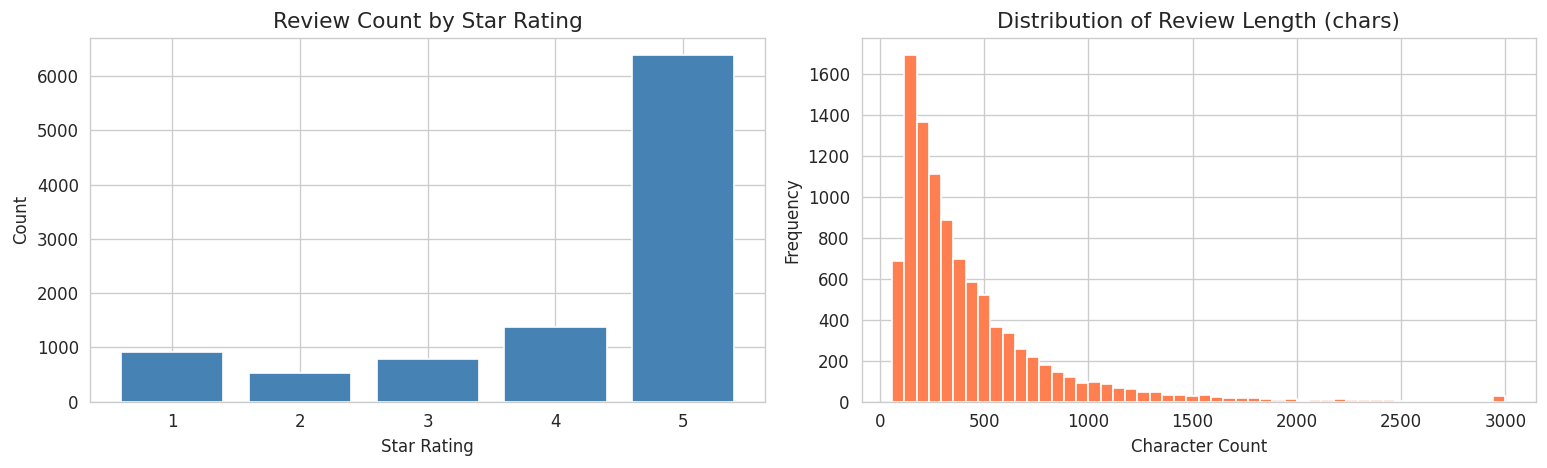

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Star rating distribution
score_counts = df_sample['Score'].value_counts().sort_index()
axes[0].bar(score_counts.index, score_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Review Count by Star Rating', fontsize=13)
axes[0].set_xlabel('Star Rating')
axes[0].set_ylabel('Count')
axes[0].set_xticks([1, 2, 3, 4, 5])

# Review length distribution
df_sample['review_length'] = df_sample['Text'].apply(len)
axes[1].hist(df_sample['review_length'].clip(upper=3000), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribution of Review Length (chars)', fontsize=13)
axes[1].set_xlabel('Character Count')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [15]:
# Average review length per star rating
avg_len = df_sample.groupby('Score')['review_length'].mean().round(0)
print('Average review length by star rating (characters):')
print(avg_len)

Average review length by star rating (characters):
Score
1    446.0
2    471.0
3    503.0
4    520.0
5    404.0
Name: review_length, dtype: float64


In [16]:
# Helpfulness ratio — what fraction of voters found the review helpful
df_sample['helpfulness_ratio'] = df_sample.apply(
    lambda row: row['HelpfulnessNumerator'] / row['HelpfulnessDenominator']
    if row['HelpfulnessDenominator'] > 0 else np.nan,
    axis=1
)

avg_helpful = df_sample.groupby('Score')['helpfulness_ratio'].mean().round(3)
print('Average helpfulness ratio by star rating:')
print(avg_helpful)

Average helpfulness ratio by star rating:
Score
1    0.527
2    0.590
3    0.626
4    0.797
5    0.874
Name: helpfulness_ratio, dtype: float64


---
## 7. Text Preprocessing

In [17]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Basic text cleaning:
    - Lowercase
    - Remove HTML tags
    - Remove punctuation and digits
    - Remove stopwords
    """
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)           # strip HTML tags
    text = re.sub(r'[^a-z\s]', '', text)        # keep only letters
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return ' '.join(tokens)

df_sample['cleaned_text'] = df_sample['Text'].apply(preprocess_text)

# Quick check
print('Original:', df_sample['Text'][0][:150])
print('\nCleaned :', df_sample['cleaned_text'][0][:150])

Original: I have tried just about every gluten free pasta available and this is hands down the BEST I have had.  Riso Bello has improved on an already great pro

Cleaned : tried every gluten free pasta available hands best riso bello improved already great product adding buckwheat mix pasta cooks perfectly dente minutes 


> **Note:** VADER is applied on the *original* review text (not the cleaned version), because VADER relies on punctuation, capitalization, and special characters to assign accurate scores. The cleaned text is used for word frequency analysis and word clouds.

---
## 8. VADER Sentiment Analysis

In [18]:
sia = SentimentIntensityAnalyzer()

# VADER returns a dict with neg, neu, pos, and compound scores
# We extract all four for completeness
def get_vader_scores(text):
    scores = sia.polarity_scores(str(text))
    return scores['neg'], scores['neu'], scores['pos'], scores['compound']

df_sample[['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']] = \
    df_sample['Text'].apply(lambda x: pd.Series(get_vader_scores(x)))

print('VADER scores added.')
df_sample[['Text', 'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']].head()

VADER scores added.


,Text,vader_neg,vader_neu,vader_pos,vader_compound
0,I have tried just about every gluten free past...,0.000,0.701,0.299,0.9851
1,I routinely purchase my dog treats through Ama...,0.033,0.902,0.065,0.1779
2,I bought this product and love it. I have deci...,0.000,0.771,0.229,0.7602
3,I've been bouncing around from one brand of gr...,0.103,0.771,0.126,0.5900
4,I get these for $4.34 at my local health food ...,0.085,0.751,0.163,0.5080


In [19]:
# Standard VADER compound score thresholds:
# compound >= 0.05  -> Positive
# compound <= -0.05 -> Negative
# in between        -> Neutral

def label_sentiment(compound):
    if compound >= 0.05:
        return 'Positive'
    elif compound <= -0.05:
        return 'Negative'
    else:
        return 'Neutral'

df_sample['sentiment'] = df_sample['vader_compound'].apply(label_sentiment)

print('Sentiment label distribution:')
print(df_sample['sentiment'].value_counts())

Sentiment label distribution:
sentiment
Positive    8748
Negative    1025
Neutral      227
Name: count, dtype: int64


---
## 9. Visualization

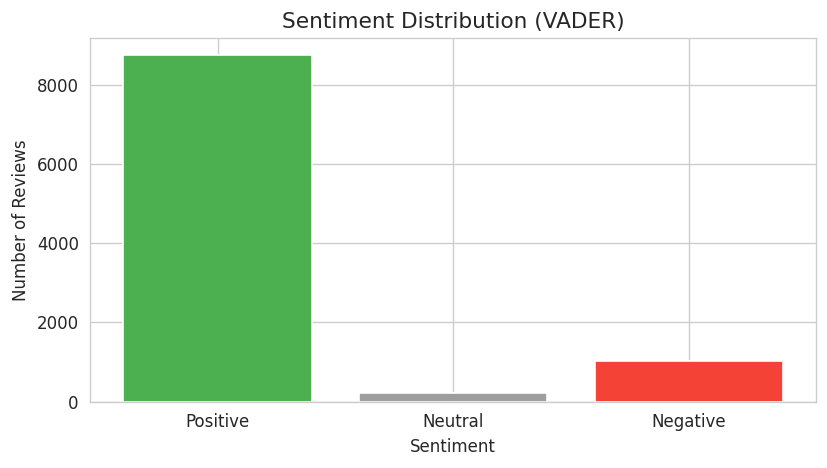

In [20]:
# --- 9.1 Overall Sentiment Distribution ---

sentiment_counts = df_sample['sentiment'].value_counts()
colors = ['#4CAF50', '#9E9E9E', '#F44336']  # green, grey, red
order = ['Positive', 'Neutral', 'Negative']

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    [s for s in order if s in sentiment_counts.index],
    [sentiment_counts[s] for s in order if s in sentiment_counts.index],
    color=[colors[order.index(s)] for s in order if s in sentiment_counts.index],
    edgecolor='white'
)
ax.set_title('Sentiment Distribution (VADER)', fontsize=13)
ax.set_ylabel('Number of Reviews')
ax.set_xlabel('Sentiment')
plt.tight_layout()
plt.show()

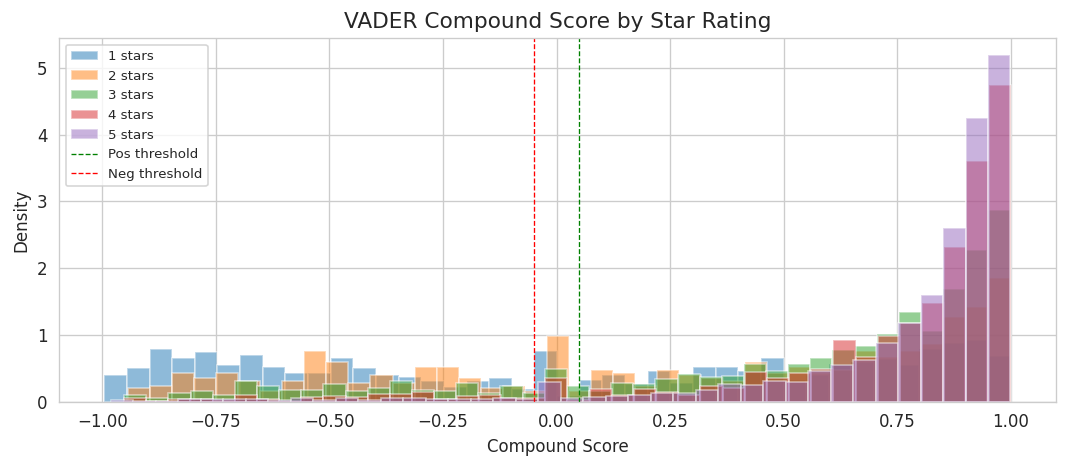

In [21]:
# --- 9.2 Compound Score Distribution by Star Rating ---

fig, ax = plt.subplots(figsize=(9, 4))
for score in sorted(df_sample['Score'].unique()):
    subset = df_sample[df_sample['Score'] == score]['vader_compound']
    ax.hist(subset, bins=40, alpha=0.5, label=f'{score} stars', density=True)

ax.axvline(0.05, color='green', linestyle='--', linewidth=0.8, label='Pos threshold')
ax.axvline(-0.05, color='red', linestyle='--', linewidth=0.8, label='Neg threshold')
ax.set_title('VADER Compound Score by Star Rating', fontsize=13)
ax.set_xlabel('Compound Score')
ax.set_ylabel('Density')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

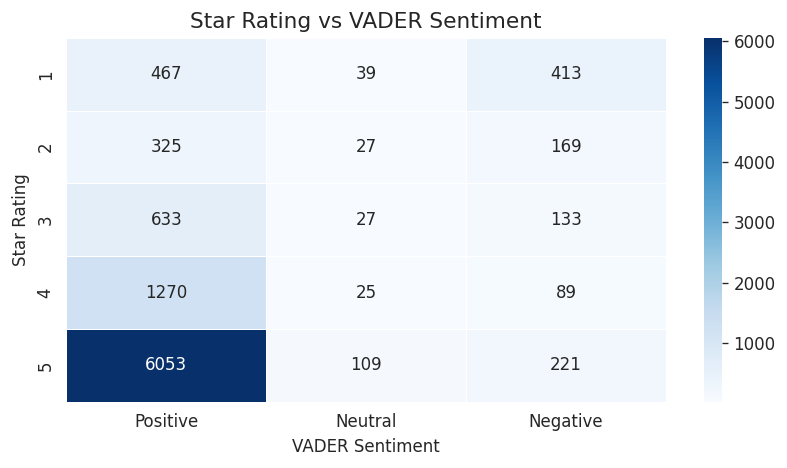

In [22]:
# --- 9.3 VADER Sentiment vs Star Rating (Heatmap) ---

cross = pd.crosstab(df_sample['Score'], df_sample['sentiment'])
cross = cross[[c for c in ['Positive', 'Neutral', 'Negative'] if c in cross.columns]]

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    cross, annot=True, fmt='d', cmap='Blues',
    linewidths=0.5, ax=ax
)
ax.set_title('Star Rating vs VADER Sentiment', fontsize=13)
ax.set_xlabel('VADER Sentiment')
ax.set_ylabel('Star Rating')
plt.tight_layout()
plt.show()

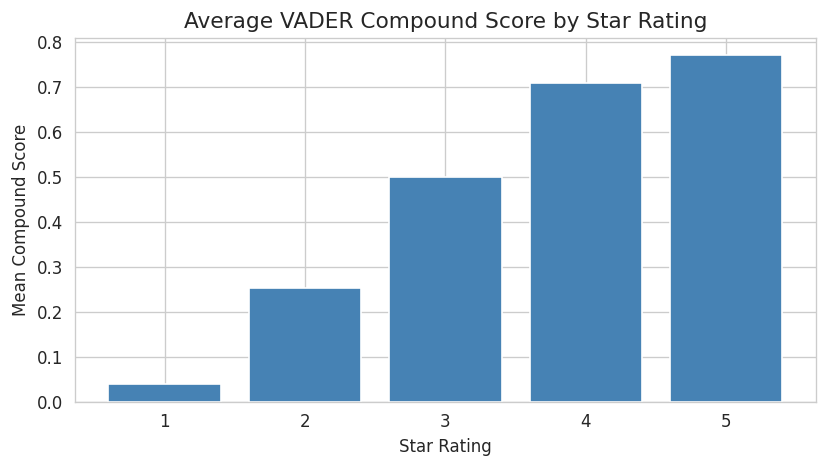

In [23]:
# --- 9.4 Average Compound Score per Star Rating ---

avg_compound = df_sample.groupby('Score')['vader_compound'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(avg_compound.index, avg_compound.values, color='steelblue', edgecolor='white')
ax.set_title('Average VADER Compound Score by Star Rating', fontsize=13)
ax.set_xlabel('Star Rating')
ax.set_ylabel('Mean Compound Score')
ax.set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

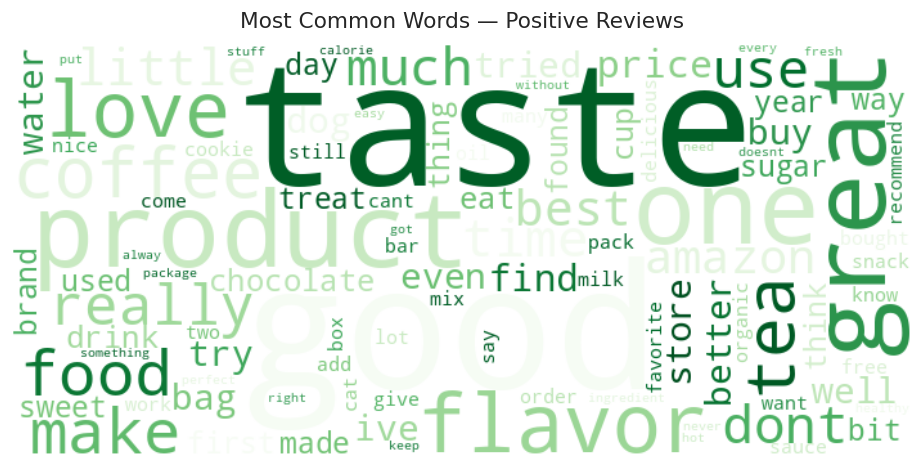

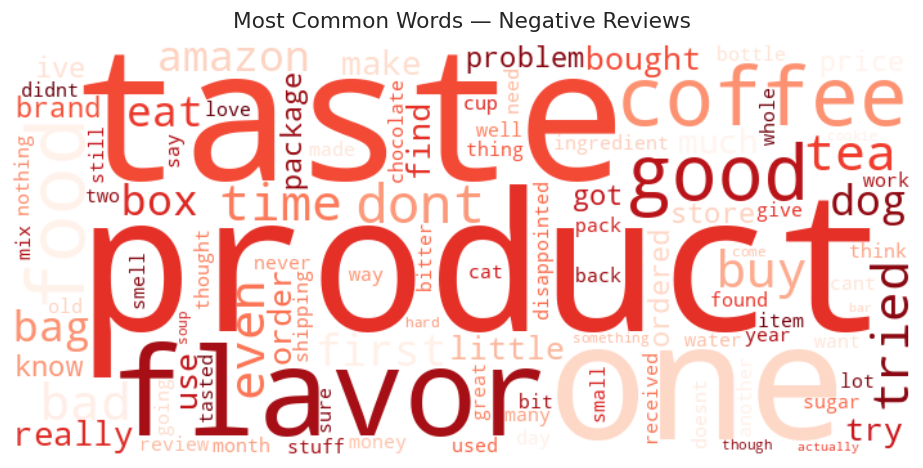

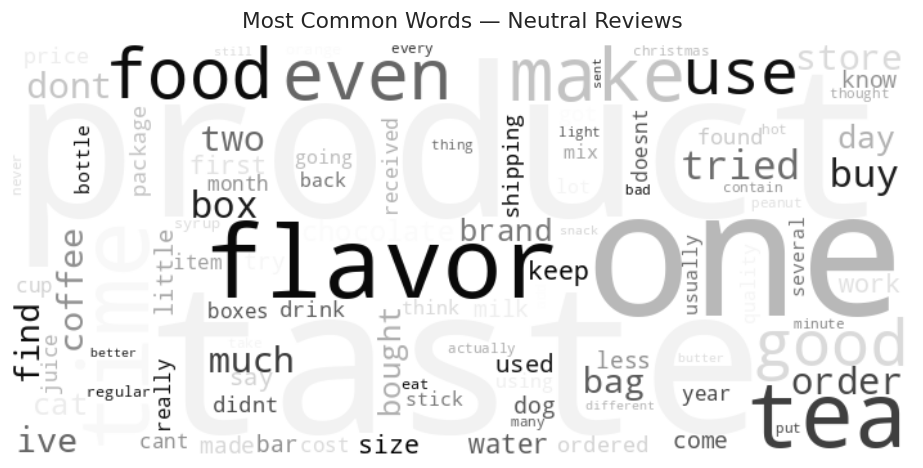

In [24]:
# --- 9.5 Word Clouds per Sentiment ---

def generate_wordcloud(text_series, title, colormap):
    combined = ' '.join(text_series.dropna())
    wc = WordCloud(
        width=700, height=320,
        background_color='white',
        colormap=colormap,
        max_words=100,
        collocations=False
    ).generate(combined)
    plt.figure(figsize=(9, 4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=13, pad=10)
    plt.tight_layout()
    plt.show()

generate_wordcloud(
    df_sample[df_sample['sentiment'] == 'Positive']['cleaned_text'],
    'Most Common Words — Positive Reviews', 'Greens'
)

generate_wordcloud(
    df_sample[df_sample['sentiment'] == 'Negative']['cleaned_text'],
    'Most Common Words — Negative Reviews', 'Reds'
)

generate_wordcloud(
    df_sample[df_sample['sentiment'] == 'Neutral']['cleaned_text'],
    'Most Common Words — Neutral Reviews', 'Greys'
)

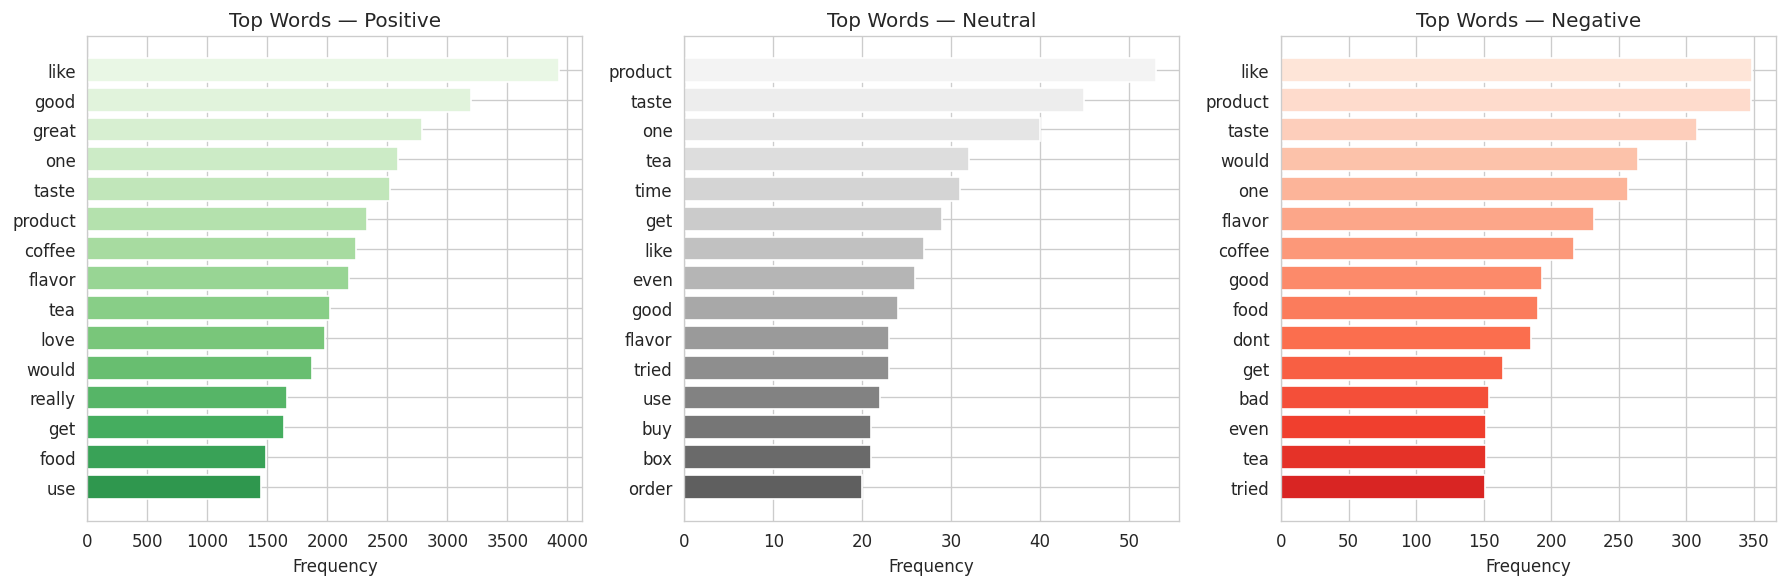

In [25]:
# --- 9.6 Top 15 Words per Sentiment ---

def top_words(text_series, n=15):
    all_words = ' '.join(text_series.dropna()).split()
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
configs = [
    ('Positive', 'Greens_r'),
    ('Neutral', 'Greys_r'),
    ('Negative', 'Reds_r'),
]

for ax, (sent, cmap) in zip(axes, configs):
    subset = df_sample[df_sample['sentiment'] == sent]['cleaned_text']
    words, counts = zip(*top_words(subset))
    colors_bar = plt.get_cmap(cmap)(np.linspace(0.3, 0.9, len(words)))
    ax.barh(words[::-1], counts[::-1], color=colors_bar)
    ax.set_title(f'Top Words — {sent}', fontsize=12)
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

---
## 10. Insights

In [26]:
# Alignment: how often does VADER sentiment agree with the star rating?
# Simple rule: 4-5 stars = expected Positive, 1-2 = expected Negative, 3 = Neutral

def expected_sentiment(score):
    if score >= 4:
        return 'Positive'
    elif score <= 2:
        return 'Negative'
    else:
        return 'Neutral'

df_sample['expected_sentiment'] = df_sample['Score'].apply(expected_sentiment)
match = (df_sample['sentiment'] == df_sample['expected_sentiment']).mean()
print(f'VADER vs Star Rating agreement: {match:.1%}')

VADER vs Star Rating agreement: 79.3%


In [27]:
# Mismatched examples — 1-star reviews VADER labels as Positive
mismatched = df_sample[
    (df_sample['Score'] == 1) & (df_sample['sentiment'] == 'Positive')
][['Score', 'Text', 'vader_compound']].head(3)

print('1-star reviews scored Positive by VADER:\n')
for _, row in mismatched.iterrows():
    print(f'  Score: {row["Score"]} | Compound: {row["vader_compound"]:.3f}')
    print(f'  Text: {row["Text"][:200]}\n')

1-star reviews scored Positive by VADER:

  Score: 1 | Compound: 0.637
  Text: Kettle chips now look, feel and taste like Lays.  These chips used to be my favorite when it was crinkle cut and hefty.  Now, no longer my favorite.

  Score: 1 | Compound: 0.850
  Text: I gave my 1 year old healthy dog one of these strips.  Within 12 hours, he began a bout of diarrhea that has now lasted 4 days; vomiting began last night.  We are on our way to the vet this morning --

  Score: 1 | Compound: 0.572
  Text: I ordered two bags and they were the same. There was not much of a variety. I would think that you would mix them up better and give a large number of different ones. I will not buy them again until y



In [28]:
# Summary stats
print('VADER Compound Score Summary:')
print(df_sample.groupby('sentiment')['vader_compound'].describe().round(3))

VADER Compound Score Summary:
            count   mean    std    min    25%    50%    75%    max
sentiment                                                         
Negative   1025.0 -0.515  0.253 -0.996 -0.731 -0.511 -0.313 -0.052
Neutral     227.0  0.000  0.013 -0.046  0.000  0.000  0.000  0.045
Positive   8748.0  0.798  0.211  0.050  0.718  0.883  0.948  1.000


**Key Takeaways:**

- The dataset is heavily skewed toward 5-star reviews, which is typical of Amazon review data.
- VADER correctly identifies sentiment in the large majority of cases when compared against star ratings.
- Mismatches often occur with sarcasm, mixed feedback, or reviews that start positively before raising a complaint — VADER has no way to model these context-level patterns.
- Negative reviews tend to be longer, likely because dissatisfied customers provide more detail.
- A rule-based method like VADER works well as a fast, lightweight baseline — it requires no training data and runs instantly.

---
## 11. Conclusion

This project applied VADER sentiment analysis to a sample of Amazon Fine Food Reviews to understand how customers feel about food products based on their written feedback.

**What we did:**
- Loaded and cleaned the dataset, removing duplicates and null values
- Performed exploratory analysis on review length, star ratings, and helpfulness
- Preprocessed text (lowercasing, punctuation removal, stopword filtering) for word-frequency tasks
- Applied VADER to the raw review text and labeled each review as Positive, Neutral, or Negative
- Visualized sentiment distribution, compound score trends, word clouds, and the relationship with star ratings

**Limitations:**
- VADER is a lexicon-based model — it doesn't understand context, sarcasm, or domain-specific language well
- The 10K sample may not fully represent the complete 568K-review dataset
- Sentiment and star rating don't always map cleanly — a 3-star review can be quite opinionated in either direction

**Possible next steps:**
- Try a transformer-based model (e.g., DistilBERT) for comparison
- Build a simple binary classifier using TF-IDF + Logistic Regression
- Analyze sentiment trends over time using the `Time` column

---
*Dataset source: [Amazon Fine Food Reviews — Kaggle](https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews)*